# Data Camp: Stress level prediction

Authors: *Lucien Perdrix, Emma de Charry, Pauline Zhou, Thibaud Geffray, Augustin Sanson*



<div style="text-align: center;">
<img src="./img/stress.jpg" width=600px alt="Stressed person"></img>
</div>


## Introduction
Stress has become an unavoidable part of modern life, affecting people of all ages and backgrounds. With increasing workloads, social pressures, financial challenges, and the constant demands of a fast-paced world, stress levels are rising globally. While short-term stress can sometimes be beneficial—helping individuals stay motivated and focused — chronic stress can have serious consequences on both physical and mental health. Factors such as irregular sleep patterns, excessive working hours, poor physical activity, and fluctuating moods can contribute to stress.

Chronic stress can lead to negative consequences like anxiety, fatigue, and even long-term health risks. Understanding and predicting stress levels based on various lifestyle and physiological factors (such as sleep quality, screen on time, ...) can help in early intervention and better stress management strategies.

Our data challenge revolves around predicting stress levels of 100 participants in order to unravel the main causes of stress, and the correlation between different factors.

# Exploratory data analysis

This notebook provides a simple exploratory data analysis of the dataset.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.base import BaseEstimator
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import is_classifier
from sklearn.compose import make_column_transformer
from sklearn import set_config
import rampwf as rw

pd.set_option('display.max_columns', None)


### Load the data

The dataset consists of 3000 rows, representing daily data for 100 participants over a period of 30 days. The data captures various psychological, behavioral, and physiological attributes for each participant. Here are the different features :
- participant_id
- day
- PSS_score: Perceived Stress Scale score, measuring stress levels
- Openness
- Conscientiousness
- Extraversion
- Agreeableness
- Neuroticism
- sleep_time
- wake_time
- sleep_duration
- PSQI_score
- call_duration
- num_calls
- num_sms
- screen_on_time
- skin_conductance
- accelerometer
- mobility_radius
- mobility_distance

Target :
- Stress_Category : PSS_score has been encoded into 3 categories based on their values (see the *preprocess.py* file for the details)

In [2]:
import problem
X_df, y = problem.get_train_data()

  
Let's first look at the data available.

In [3]:
print(f"There are {X_df.shape[0]} segment in this dataset.")
X_df.head()

There are 2399 segment in this dataset.


,participant_id,day,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism,sleep_time,wake_time,sleep_duration,PSQI_score,call_duration,num_calls,num_sms,screen_on_time,skin_conductance,accelerometer,mobility_radius,mobility_distance
0,1,1,2.322732,4.332193,1.185878,1.570213,3.782094,7.726792,5.190660,6.572069,1,3.924527,12,32,10.703714,3.115730,0.161717,1.145179,2.196851
1,1,2,1.761436,3.254120,3.907281,4.072512,1.997145,7.312674,6.170717,8.030168,4,58.318004,3,41,11.012939,0.959144,0.985587,1.021133,0.737825
2,1,3,3.025887,1.855002,2.045900,2.317493,3.619225,6.992060,5.318825,7.102420,1,4.941043,4,48,4.877372,3.311629,1.877445,0.478179,0.911673
3,1,4,1.948370,4.966676,3.345225,1.607756,3.583524,8.886914,8.061075,8.123294,3,0.295373,11,38,3.462956,0.625721,0.494921,0.630549,3.911418
4,1,5,3.343484,2.065936,3.137843,2.118061,2.567347,7.811705,7.312145,7.785143,3,22.300571,17,17,4.861046,0.622609,1.342600,0.254090,1.605132


<Axes: >

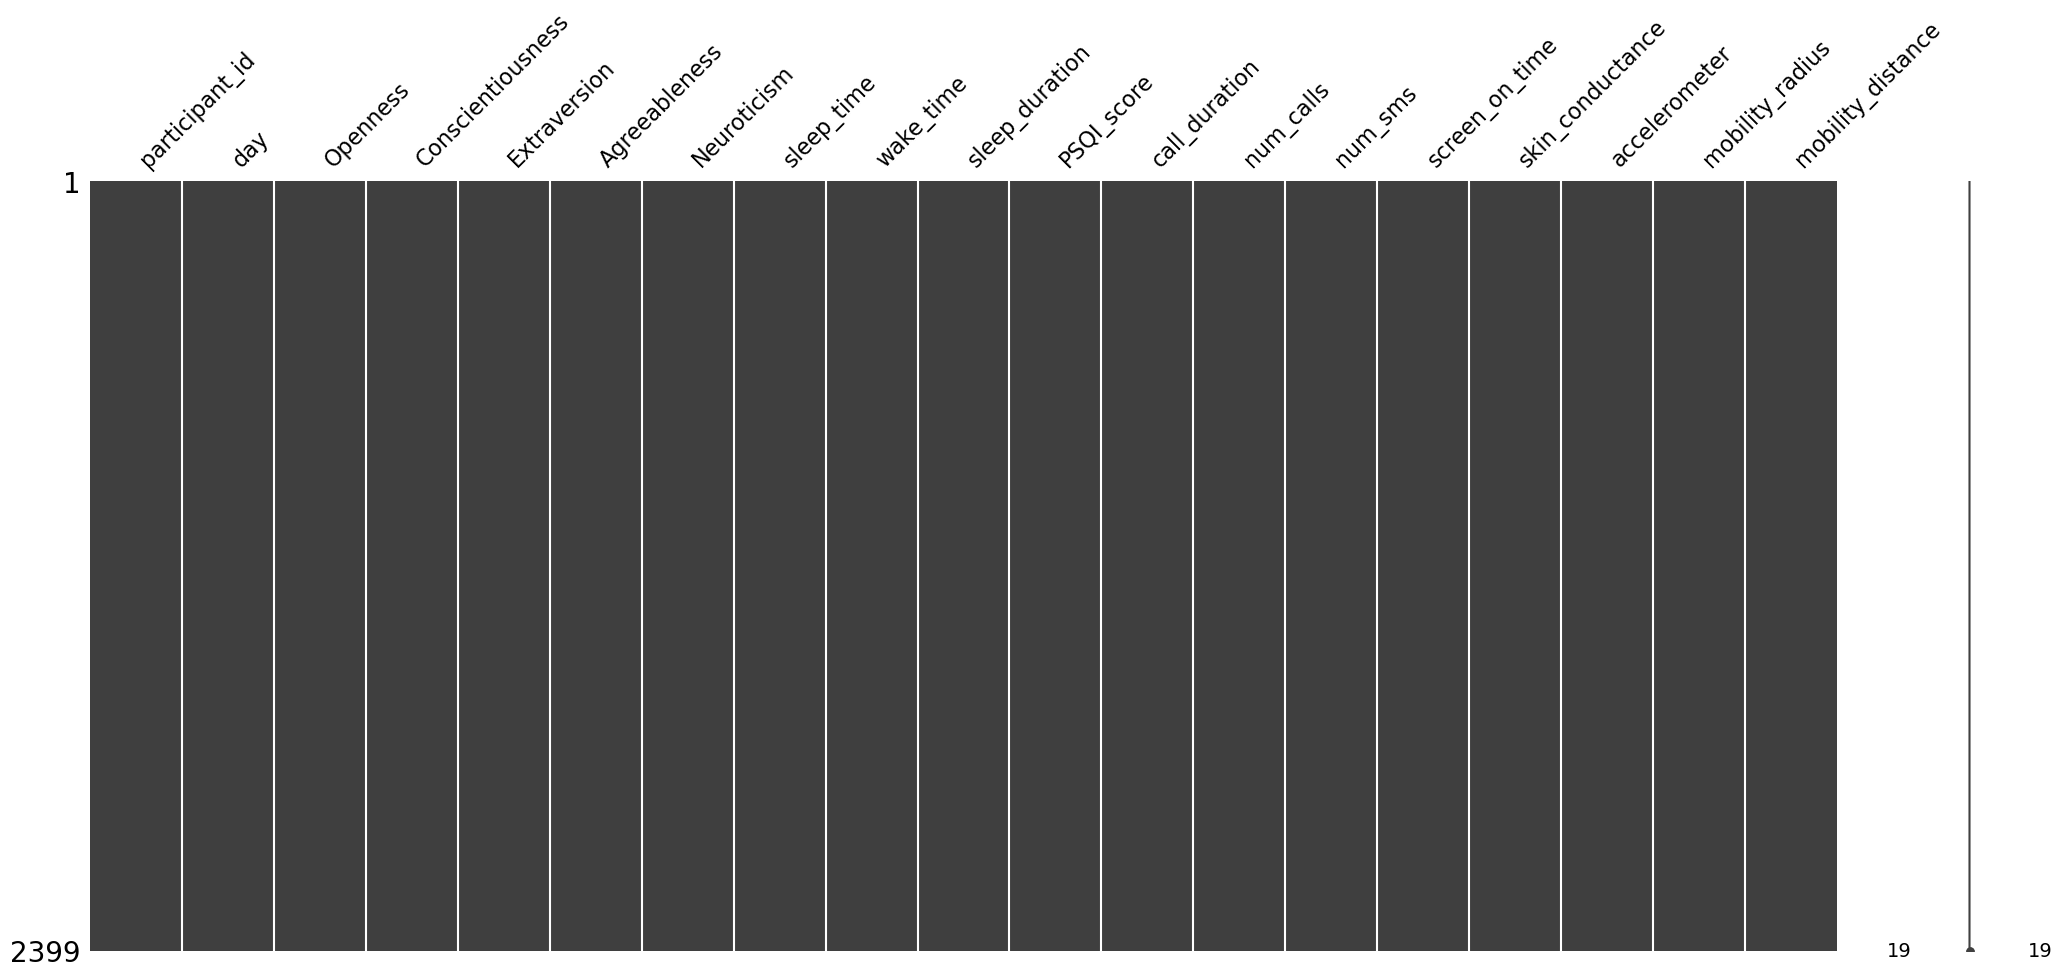

In [4]:
msno.matrix(X_df) # Visualize missing values as a matrix

We see that there are no missing values in the data set.

There are 80 unique subjects in the train set.


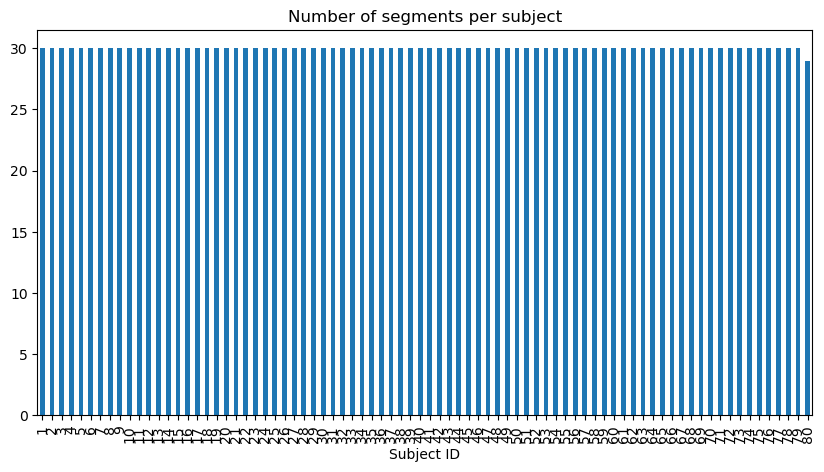

In [5]:
print(
    f"There are {X_df['participant_id'].nunique()} unique subjects in the train set."
)
plt.figure(figsize=(10, 5))
X_df['participant_id'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Subject ID')
plt.title('Number of segments per subject')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


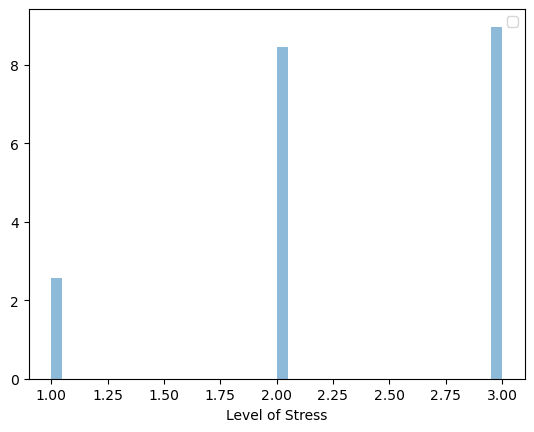

In [13]:
# Now let's check the distribution of the target
plt.hist(y, bins=40, density=True, alpha=0.5)
plt.xlabel('Level of Stress')
plt.legend()

In [18]:
y_df = pd.DataFrame(y, columns=['PSS_score'])

In [15]:
X_df_original = pd.concat([X_df, y_df], axis=1)
X_df_original.head()

,participant_id,day,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism,sleep_time,wake_time,sleep_duration,PSQI_score,call_duration,num_calls,num_sms,screen_on_time,skin_conductance,accelerometer,mobility_radius,mobility_distance,PSS_score
0,1,1,2.322732,4.332193,1.185878,1.570213,3.782094,7.726792,5.190660,6.572069,1,3.924527,12,32,10.703714,3.115730,0.161717,1.145179,2.196851,3
1,1,2,1.761436,3.254120,3.907281,4.072512,1.997145,7.312674,6.170717,8.030168,4,58.318004,3,41,11.012939,0.959144,0.985587,1.021133,0.737825,3
2,1,3,3.025887,1.855002,2.045900,2.317493,3.619225,6.992060,5.318825,7.102420,1,4.941043,4,48,4.877372,3.311629,1.877445,0.478179,0.911673,3
3,1,4,1.948370,4.966676,3.345225,1.607756,3.583524,8.886914,8.061075,8.123294,3,0.295373,11,38,3.462956,0.625721,0.494921,0.630549,3.911418,2
4,1,5,3.343484,2.065936,3.137843,2.118061,2.567347,7.811705,7.312145,7.785143,3,22.300571,17,17,4.861046,0.622609,1.342600,0.254090,1.605132,3


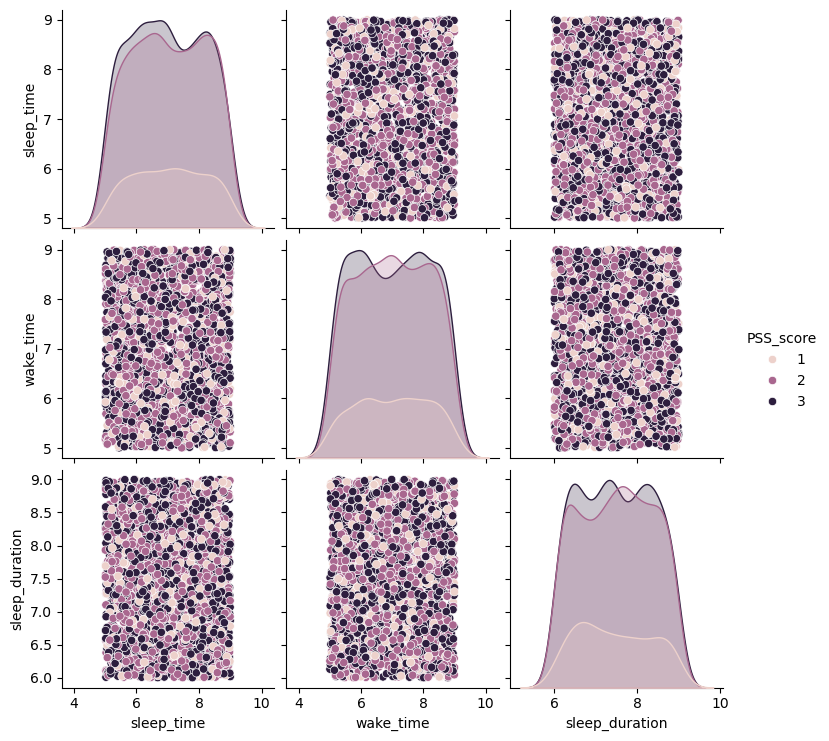

In [16]:
sns.pairplot(X_df_original[['PSS_score','sleep_time','wake_time','sleep_duration']], hue="PSS_score")

The pair plots show that the variables `sleep_time`, `wake_time`, and `sleep_duration` have similar distributions for the different categories of `PSS_score`. The scatter plots indicate that the relationships between these variables do not show a clear trend based on the categories of `PSS_score`. This suggests that these variables may not be strongly correlated with the stress levels measured by `PSS_score`.

In [6]:
X_test_df, y_test = problem.get_test_data()
X_test_df.head()

,participant_id,day,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism,sleep_time,wake_time,sleep_duration,PSQI_score,call_duration,num_calls,num_sms,screen_on_time,skin_conductance,accelerometer,mobility_radius,mobility_distance
0,80,30,4.225196,1.090630,4.576529,4.201433,1.331422,8.031646,7.232551,7.995368,1,58.746427,1,22,1.609923,3.180002,0.251021,0.254153,1.116456
1,81,1,3.213183,1.389810,2.027371,2.950340,1.258817,7.061102,8.194204,6.879856,1,1.382396,8,18,8.871625,3.925718,1.015649,0.775236,2.606895
2,81,2,3.817686,2.016548,2.260803,4.511570,3.615620,7.748077,5.200240,6.694159,3,17.681286,5,15,9.428218,2.833281,1.152411,1.165975,0.567149
3,81,3,1.550248,1.053309,2.068540,3.453630,1.086103,7.281832,8.306446,6.315801,3,55.319799,6,0,9.245506,2.255333,2.140438,1.384977,3.682635
4,81,4,1.724213,1.240446,2.039920,3.202738,1.121444,7.192350,5.919280,8.493947,3,19.716812,18,49,3.052984,0.624979,0.402647,0.653080,3.341838


There are 21 unique subjects in the test set.


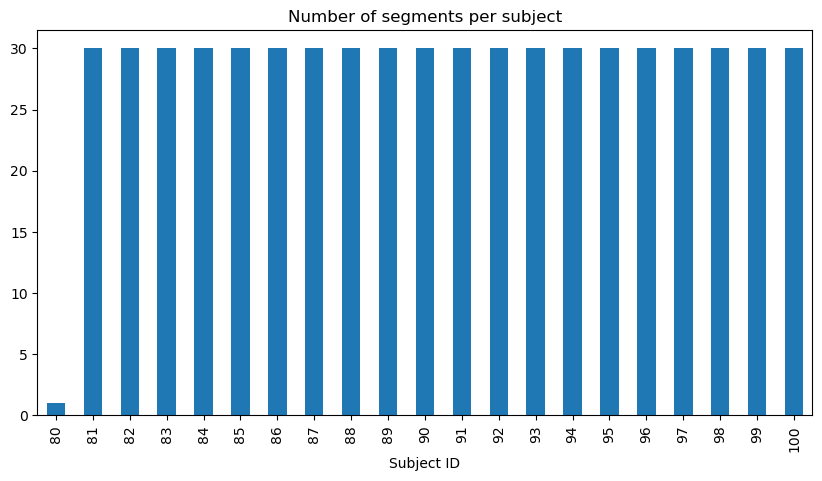

In [7]:
print(
    f"There are {X_test_df['participant_id'].nunique()} unique subjects in the test set."
)
plt.figure(figsize=(10, 5))
X_test_df['participant_id'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Subject ID')
plt.title('Number of segments per subject')
plt.show()

### A first model 

In [8]:
X_train_df, y_train = problem.get_train_data()
X_test_df, y_test = problem.get_test_data()

# The model will take numpy arrays as input.
X_train = X_train_df.to_numpy()

X_test = X_test_df.to_numpy()


numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),  
        ("scaler", StandardScaler())  
])

clf_lr = Pipeline(
    steps=[("transformer", numeric_transformer), ("classifier", LogisticRegression(max_iter=500))]
)

clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)


print("balanced accuracy score linear regressor (score to beat) = ", balanced_accuracy_score(y_test, y_pred_lr))

balanced accuracy score linear regressor (score to beat) =  0.3579745575964009


## The pipeline workflow

The input data are stored in a dataframe. To go from a dataframe to a numpy array we will use a scikit-learn column transformer. The first example we will write will just consist in selecting a subset of columns we want to work with.

In [14]:

from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

set_config(transform_output="pandas")


class IgnoreDomain(RandomForestRegressor):
    def fit(self, X, y):
        # Ignore the samples with missing target
        X = X[y != -1]
        y = y[y != -1]
        return super().fit(X, y)


def get_estimator():
    return make_pipeline(
        make_column_transformer(
            ("passthrough", ["age"]),
            (OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ), ["gender"]),
        ),
        IgnoreDomain(n_estimators=50)
    )
